<a href="https://colab.research.google.com/github/Anisha-2404/breast-cancer-diagnosis/blob/main/Breast_cancer_diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
from google.colab import files
[]
uploaded = files.upload()


Saving breast-cancer.csv to breast-cancer.csv


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)


In [45]:
df = pd.read_csv("breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [46]:
print("number of rows and columns", df.shape)

number of rows and columns (569, 32)


In [47]:
print("\nColumn Names: ")
print(df.columns.tolist())
print("\nDataset Information")
df.info()


Column Names: 
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean      

In [50]:
for column in df.select_dtypes(include="object").columns:
    unknown_count = (df[column] == "unknown").sum()
    if unknown_count > 0:
        print(column, ":", unknown_count)

In [51]:
print("Duplicate Rows: ", df.duplicated().sum())
df = df.drop_duplicates()
print("Shapes after removing Duplicates", df.shape )

Duplicate Rows:  0
Shapes after removing Duplicates (569, 32)


In [53]:
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


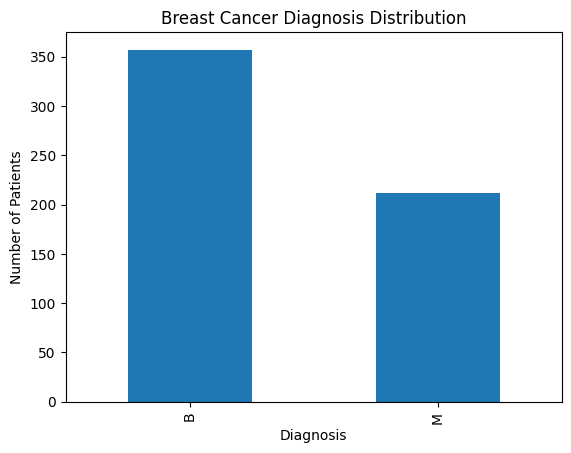

In [54]:
df["diagnosis"].value_counts().plot(kind="bar")

plt.title("Breast Cancer Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()

In [55]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(df["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [56]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [57]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [58]:
categorical_columns = X.select_dtypes(
    include = ["object"]
).columns.tolist()

In [59]:
print("Numerical Columns are: ", numerical_columns)

Numerical Columns are:  ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [60]:
print("Categorical Columns are : ", categorical_columns)

Categorical Columns are :  []


In [62]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [63]:
print("Training Data Shape: " , X_train.shape)
print("Testing Data Shape: ", X_test.shape)

Training Data Shape:  (455, 31)
Testing Data Shape:  (114, 31)


In [65]:
numerical_pipeline = Pipeline(
    steps=[
        (
          "missing values",
          SimpleImputer(strategy="median")
        )
    ]
)


In [67]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "missing values",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoding",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [68]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [69]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_columns

        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [70]:
model = Pipeline(
    steps=[
        (
          "preprocessing",
           preprocessor
        ),
        (
            "random_forest",
            random_forest
        )
    ]
)

In [71]:
model.fit(X_train, y_train)
print("Model Training Complete")

Model Training Complete


In [72]:
predictions =  model.predict(X_test)
print(predictions[:20])

[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [73]:
probablities = model.predict_proba(X_test)
print(probablities[:20])

[[0.98  0.02 ]
 [0.005 0.995]
 [0.7   0.3  ]
 [0.355 0.645]
 [0.93  0.07 ]
 [0.935 0.065]
 [0.39  0.61 ]
 [0.89  0.11 ]
 [0.995 0.005]
 [1.    0.   ]
 [0.015 0.985]
 [0.985 0.015]
 [0.    1.   ]
 [1.    0.   ]
 [0.985 0.015]
 [0.975 0.025]
 [0.74  0.26 ]
 [0.995 0.005]
 [0.78  0.22 ]
 [0.985 0.015]]


In [74]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", round(accuracy*100,2),"%")

Accuracy:  97.37 %


In [75]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.96      1.00      0.98        72
         Yes       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



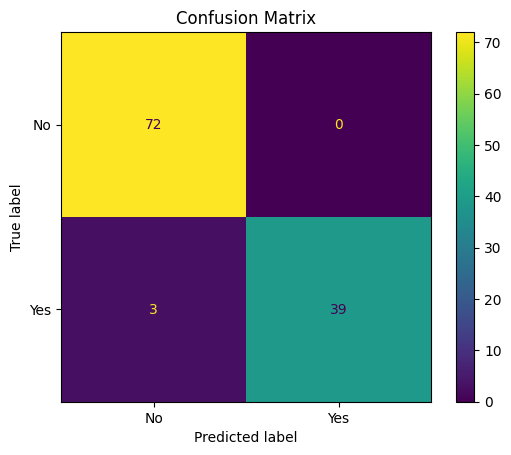

In [76]:
cm = confusion_matrix(y_test, predictions)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)
display.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#roc - receiver operator characteristic curve
# auc area under the curve

In [77]:
roc_auc = roc_auc_score(y_test, probablities[:,1])
print("ROC AUC Score: ", round(roc_auc*100,2),"%")

ROC AUC Score:  99.75 %


In [79]:
import joblib

joblib.dump(
    model,
    "breast_cancer_random_forest_model.pkl"
)

['breast_cancer_random_forest_model.pkl']

In [80]:
from google.colab import files

files.download(
    "breast_cancer_random_forest_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>